<a href="https://colab.research.google.com/github/myra573/MeeraS/blob/main/flightpriceprediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd

# Raw GitHub URL
url = "https://raw.githubusercontent.com/MasteriNeuron/datasets/main/flight_price.csv"

# Load the dataset
df = pd.read_csv(url)

# Display the first 5 rows
df.head()

,Unnamed: 0,airline,flight,source_city,departure_time,stops,arrival_time,destination_city,class,duration,days_left,price
0,0,SpiceJet,SG-8709,Delhi,Evening,zero,Night,Mumbai,Economy,2.17,1,5953
1,1,SpiceJet,SG-8157,Delhi,Early_Morning,zero,Morning,Mumbai,Economy,2.33,1,5953
2,2,AirAsia,I5-764,Delhi,Early_Morning,zero,Early_Morning,Mumbai,Economy,2.17,1,5956
3,3,Vistara,UK-995,Delhi,Morning,zero,Afternoon,Mumbai,Economy,2.25,1,5955
4,4,Vistara,UK-963,Delhi,Morning,zero,Morning,Mumbai,Economy,2.33,1,5955


In [2]:
# Check the shape of the dataset
print("Shape:", df.shape)

# Display column names
print("\nColumns:")
print(df.columns)

# Display dataset information
print("\nDataset Info:")
df.info()

# Check for missing values
print("\nMissing Values:")
print(df.isnull().sum())

# Summary statistics
print("\nSummary Statistics:")
df.describe()

Shape: (300153, 12)

Columns:
Index(['Unnamed: 0', 'airline', 'flight', 'source_city', 'departure_time',
       'stops', 'arrival_time', 'destination_city', 'class', 'duration',
       'days_left', 'price'],
      dtype='object')

Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 300153 entries, 0 to 300152
Data columns (total 12 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   Unnamed: 0        300153 non-null  int64  
 1   airline           300153 non-null  object 
 2   flight            300153 non-null  object 
 3   source_city       300153 non-null  object 
 4   departure_time    300153 non-null  object 
 5   stops             300153 non-null  object 
 6   arrival_time      300153 non-null  object 
 7   destination_city  300153 non-null  object 
 8   class             300153 non-null  object 
 9   duration          300153 non-null  float64
 10  days_left         300153 non-null  int64  
 11  price          

,Unnamed: 0,duration,days_left,price
count,300153.000000,300153.000000,300153.000000,300153.000000
mean,150076.000000,12.221021,26.004751,20889.660523
std,86646.852011,7.191997,13.561004,22697.767366
min,0.000000,0.830000,1.000000,1105.000000
25%,75038.000000,6.830000,15.000000,4783.000000
50%,150076.000000,11.250000,26.000000,7425.000000
75%,225114.000000,16.170000,38.000000,42521.000000
max,300152.000000,49.830000,49.000000,123071.000000


In [3]:
# Display 10 random rows
df.sample(10)

,Unnamed: 0,airline,flight,source_city,departure_time,stops,arrival_time,destination_city,class,duration,days_left,price
147187,147187,AirAsia,I5-2473,Kolkata,Morning,one,Evening,Hyderabad,Economy,8.08,42,4589
137962,137962,Air_India,AI-770,Kolkata,Night,one,Night,Bangalore,Economy,23.58,19,7053
238375,238375,Vistara,UK-940,Mumbai,Evening,one,Morning,Hyderabad,Business,13.92,7,60365
30371,30371,Air_India,AI-636,Delhi,Afternoon,one,Night,Hyderabad,Economy,7.08,15,4839
257349,257349,Vistara,UK-864,Bangalore,Evening,one,Night,Hyderabad,Business,25.92,24,37985
173135,173135,Indigo,6E-6719,Hyderabad,Morning,one,Evening,Kolkata,Economy,9.17,23,5750
123688,123688,Air_India,AI-676,Kolkata,Morning,one,Evening,Delhi,Economy,9.67,27,5810
56562,56562,AirAsia,I5-423,Mumbai,Afternoon,one,Night,Bangalore,Economy,7.50,23,2074
24610,24610,GO_FIRST,G8-113,Delhi,Early_Morning,one,Evening,Kolkata,Economy,11.92,26,7790
96734,96734,Air_India,AI-804,Bangalore,Early_Morning,one,Evening,Mumbai,Economy,13.83,17,6578


In [4]:
avg_price = df.groupby('days_left')['price'].mean().reset_index()

print(avg_price.head())

   days_left         price
0          1  21591.867151
1          2  30211.299801
2          3  28976.083569
3          4  25730.905653
4          5  26679.773368


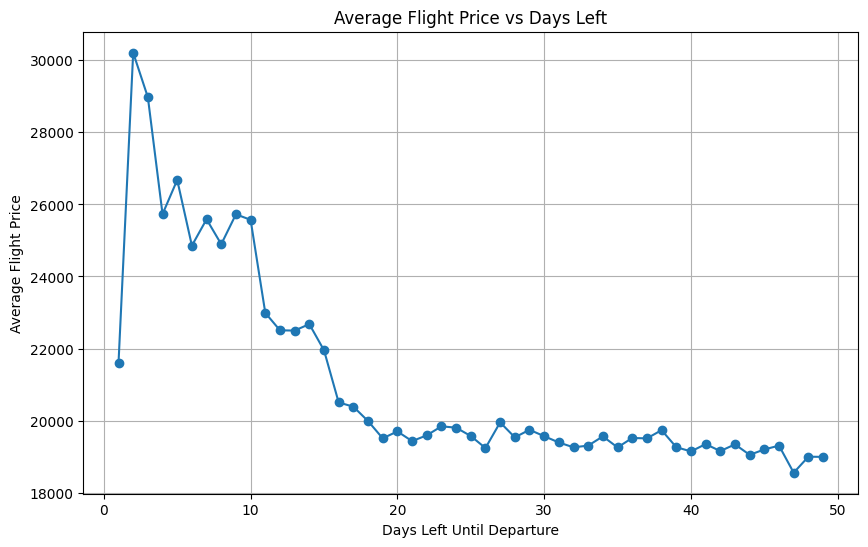

In [5]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))

plt.plot(avg_price['days_left'],
         avg_price['price'],
         marker='o')

plt.title("Average Flight Price vs Days Left")
plt.xlabel("Days Left Until Departure")
plt.ylabel("Average Flight Price")

plt.grid(True)

plt.show()

In [6]:
lowest = avg_price.loc[avg_price['price'].idxmin()]

print("Cheapest Booking Window")
print(lowest)

Cheapest Booking Window
days_left       47.000000
price        18553.272038
Name: 46, dtype: float64


The analysis indicates a negative relationship between days left until departure and flight price. As the number of days left decreases, the average ticket price increases. A noticeable price surge occurs in the last 10–15 days before departure, with the highest prices typically observed in the final few days. Therefore, the best booking window is approximately 25–45 days before departure, when average ticket prices are lowest. Booking early helps travelers avoid the sharp increase in prices that occurs closer to the departure date.

In [7]:
# Filter flights from Delhi to Mumbai
route_df = df[(df['source_city'] == 'Delhi') &
              (df['destination_city'] == 'Mumbai')]

route_df.head()

,Unnamed: 0,airline,flight,source_city,departure_time,stops,arrival_time,destination_city,class,duration,days_left,price
0,0,SpiceJet,SG-8709,Delhi,Evening,zero,Night,Mumbai,Economy,2.17,1,5953
1,1,SpiceJet,SG-8157,Delhi,Early_Morning,zero,Morning,Mumbai,Economy,2.33,1,5953
2,2,AirAsia,I5-764,Delhi,Early_Morning,zero,Early_Morning,Mumbai,Economy,2.17,1,5956
3,3,Vistara,UK-995,Delhi,Morning,zero,Afternoon,Mumbai,Economy,2.25,1,5955
4,4,Vistara,UK-963,Delhi,Morning,zero,Morning,Mumbai,Economy,2.33,1,5955


In [8]:
avg_price = route_df.groupby('airline')['price'].mean().sort_values()

print(avg_price)

airline
AirAsia       3981.191456
Indigo        4473.739130
SpiceJet      4628.251984
GO_FIRST      5762.211515
Air_India    23695.916916
Vistara      26630.293322
Name: price, dtype: float64


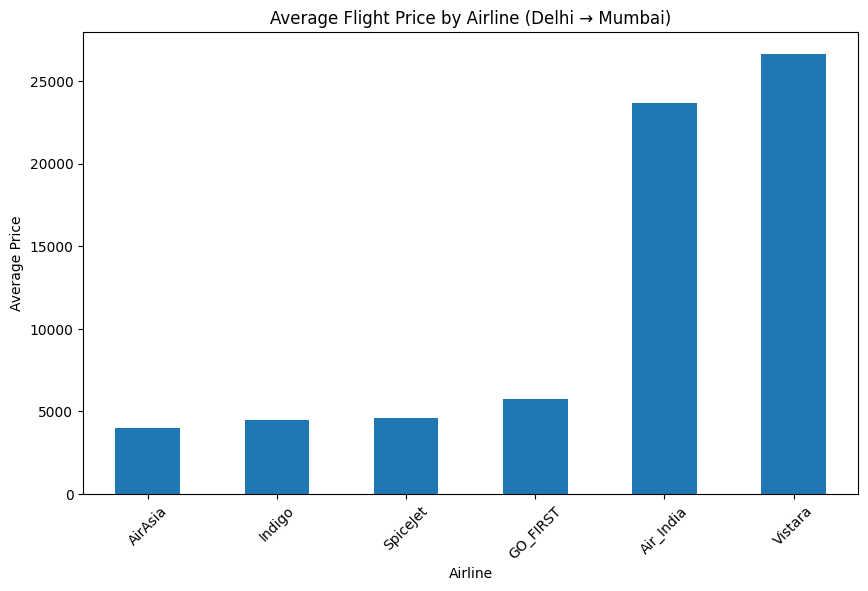

In [9]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))

avg_price.plot(kind='bar')

plt.title('Average Flight Price by Airline (Delhi → Mumbai)')
plt.xlabel('Airline')
plt.ylabel('Average Price')

plt.xticks(rotation=45)

plt.show()

In [10]:
print("Cheapest Airline:")
print(avg_price.idxmin(), "-", round(avg_price.min(), 2))

print("\nMost Expensive Airline:")
print(avg_price.idxmax(), "-", round(avg_price.max(), 2))

Cheapest Airline:
AirAsia - 3981.19

Most Expensive Airline:
Vistara - 26630.29


For the Delhi–Mumbai route, budget airlines (e.g., AirAsia, Indigo, and GO_FIRST) are generally the cheapest, while Vistara and Air India are typically more expensive. The price difference is mainly due to differences in service quality, baggage policies, onboard amenities, and the overall business model. Travelers seeking lower fares usually choose budget airlines, whereas those prioritizing comfort and additional services often opt for premium carriers.